[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.3_instance_selection/lab.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.cloud.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.3_instance_selection/lab.ipynb)

# Lab 2.3: Instance Selection Calculator

Pick your model and requirements. Get the cheapest GPU that works.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

# GPU instance catalog: real cloud offerings
GPU_INSTANCES = {
    "A10G (24GB)": {"vram_gb": 24, "bandwidth_gbs": 600, "flops_tflops": 31.2, "cost_per_hr": 1.01},
    "L4 (24GB)": {"vram_gb": 24, "bandwidth_gbs": 300, "flops_tflops": 30.3, "cost_per_hr": 0.81},
    "A100 40GB": {"vram_gb": 40, "bandwidth_gbs": 1555, "flops_tflops": 77.9, "cost_per_hr": 3.67},
    "A100 80GB": {"vram_gb": 80, "bandwidth_gbs": 2039, "flops_tflops": 77.9, "cost_per_hr": 5.12},
    "H100 80GB": {"vram_gb": 80, "bandwidth_gbs": 3350, "flops_tflops": 267.6, "cost_per_hr": 8.10},
    "L40S (48GB)": {"vram_gb": 48, "bandwidth_gbs": 864, "flops_tflops": 91.6, "cost_per_hr": 2.40},
    "H200 (141GB)": {"vram_gb": 141, "bandwidth_gbs": 4800, "flops_tflops": 267.6, "cost_per_hr": 12.50},
    "MI300X (192GB)": {"vram_gb": 192, "bandwidth_gbs": 5300, "flops_tflops": 163.4, "cost_per_hr": 10.00},
}

# Bytes per parameter by precision
PRECISION_BYTES = {"FP16": 2, "INT8": 1, "INT4": 0.5}

# Model sizes in billions of parameters
MODEL_PARAMS = {"7B": 7, "13B": 13, "70B": 70, "405B": 405}

## Interactive Instance Selector

In [7]:
# Model selection widgets
model_dd = widgets.Dropdown(options=["7B", "13B", "70B", "405B"], value="7B", description="Model:")
prec_dd = widgets.Dropdown(options=["FP16", "INT8", "INT4"], value="FP16", description="Precision:")
ctx_slider = widgets.IntSlider(value=4096, min=512, max=32768, step=512, description="Context:")
batch_slider = widgets.IntSlider(value=8, min=1, max=128, step=1, description="Batch Size:")
itl_slider = widgets.FloatSlider(value=50.0, min=5.0, max=200.0, step=5.0, description="Max ITL (ms):")
out = widgets.Output()

def evaluate_instances(model, precision, tokens_per_conversation, batch_size, max_itl_ms):
    """Check each GPU against model requirements."""
    params_b = MODEL_PARAMS[model]
    bytes_per_param = PRECISION_BYTES[precision]
    # Model weight memory in GB
    weight_gb = params_b * bytes_per_param
    # KV cache per token per layer: 2 * hidden * 2 bytes (FP16 KV always)
    # Approximate: hidden ~ params_b * 1024 / 7 for scaling, layers ~ params_b * 32 / 7
    hidden = int(params_b * 1024 / 7) * 7  # rough scaling
    layers = int(params_b * 32 / 7)
    kv_per_token_gb = 2 * hidden * 2 * layers / 1e9  # 2 matrices, 2 bytes each
    kv_total_gb = kv_per_token_gb * tokens_per_conversation * batch_size
    total_vram_gb = weight_gb + kv_total_gb
    # ITL estimate: weight_gb * 1e9 / bandwidth_bytes_per_sec * 1000 (ms)
    results = []
    for name, spec in GPU_INSTANCES.items():
        vram_ok = total_vram_gb <= spec["vram_gb"] * 0.9  # 90% usable
        # Min ITL: time to read all weights once per token
        min_itl_ms = (weight_gb * 1e3) / spec["bandwidth_gbs"]  # GB / (GB/s) = seconds, *1e3 = ms
        itl_ok = min_itl_ms <= max_itl_ms
        passes = vram_ok and itl_ok
        results.append({"name": name, "vram_ok": vram_ok, "itl_ok": itl_ok,
                        "passes": passes, "min_itl_ms": min_itl_ms,
                        "total_vram_gb": total_vram_gb, "cost": spec["cost_per_hr"]})
    return sorted(results, key=lambda x: (not x["passes"], x["cost"]))

def on_change(_):
    out.clear_output()
    with out:
        results = evaluate_instances(model_dd.value, prec_dd.value,
                                     ctx_slider.value, batch_slider.value, itl_slider.value)
        # Build HTML table
        html = "<table style='border-collapse:collapse;width:100%'>"
        html += "<tr style='background:#f3f4f6'><th>Instance</th><th>VRAM</th><th>ITL</th><th>Cost/hr</th><th>Status</th></tr>"
        for r in results:
            color = "#dcfce7" if r["passes"] else "#ffe4e6"  # green pass, rose fail
            status = "\u2705 PASS" if r["passes"] else "\u274c FAIL"
            html += f"<tr style='background:{color}'><td>{r['name']}</td><td>{r['total_vram_gb']:.1f}/{GPU_INSTANCES[r['name']]['vram_gb']}GB</td>"
            html += f"<td>{r['min_itl_ms']:.1f}ms</td><td>${r['cost']:.2f}</td><td>{status}</td></tr>"
        html += "</table>"
        display(HTML(html))

# Connect widgets
for w in [model_dd, prec_dd, ctx_slider, batch_slider, itl_slider]:
    w.observe(on_change, names='value')

display(widgets.VBox([model_dd, prec_dd, ctx_slider, batch_slider, itl_slider, out]))
on_change(None)  # Initial render

## Cost Comparison

/tmp/ipykernel_13078/1616886878.py:30: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jharshul/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


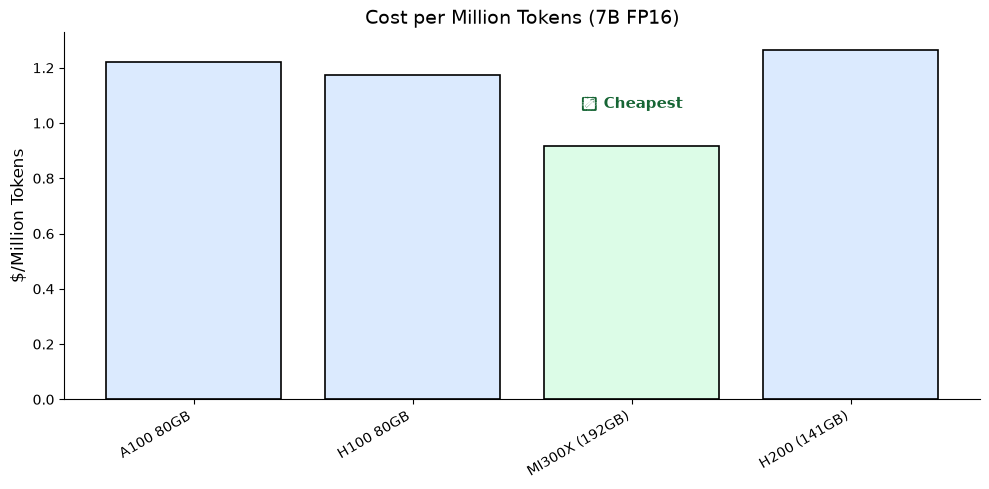

In [3]:
def plot_cost_comparison(model, precision, tokens_per_conversation, batch_size, max_itl_ms):
    """Bar chart: $/million tokens for passing instances."""
    results = evaluate_instances(model, precision, tokens_per_conversation, batch_size, max_itl_ms)
    passing = [r for r in results if r["passes"]]
    if not passing:
        print("No instances pass all constraints. Try smaller model or relaxed requirements.")
        return
    # Estimate tokens/hr: 1000ms/min_itl * 3600 * batch_size
    names, costs_per_mtok = [], []
    for r in passing:
        tokens_per_sec = batch_size / (r["min_itl_ms"] / 1000)  # tokens/sec across batch
        tokens_per_hr = tokens_per_sec * 3600
        cost_per_mtok = (r["cost"] / tokens_per_hr) * 1e6  # $/million tokens
        names.append(r["name"])
        costs_per_mtok.append(cost_per_mtok)

    # Pastel bar colors
    colors = ["#dbeafe" if c != min(costs_per_mtok) else "#dcfce7" for c in costs_per_mtok]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(names, costs_per_mtok, color=colors, edgecolor="#000", linewidth=1.2)
    # Annotate cheapest
    min_idx = costs_per_mtok.index(min(costs_per_mtok))
    ax.annotate("\u2b50 Cheapest", xy=(min_idx, costs_per_mtok[min_idx]),
               xytext=(min_idx, costs_per_mtok[min_idx] * 1.15),
               ha="center", fontsize=11, fontweight="bold", color="#166534")
    ax.set_ylabel("$/Million Tokens", fontsize=12)
    ax.set_title(f"Cost per Million Tokens ({model} {precision})", fontsize=14)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Run with defaults
plot_cost_comparison("7B", "FP16", 4096, 8, 50.0)

## Bandwidth Check

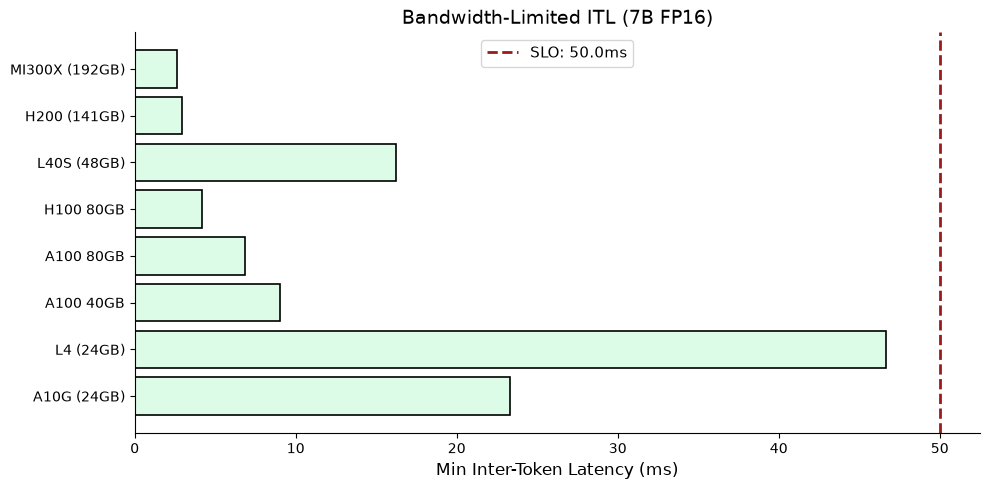

In [4]:
def plot_bandwidth_check(model, precision, max_itl_ms):
    """Horizontal bar chart showing min ITL per instance vs SLO."""
    params_b = MODEL_PARAMS[model]
    weight_gb = params_b * PRECISION_BYTES[precision]
    names, itls = [], []
    for name, spec in GPU_INSTANCES.items():
        # Min ITL = time to stream all weights through memory bus
        min_itl = (weight_gb * 1e3) / spec["bandwidth_gbs"]
        names.append(name)
        itls.append(min_itl)

    # Color: green if under SLO, rose if over
    colors = ["#dcfce7" if t <= max_itl_ms else "#ffe4e6" for t in itls]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(names, itls, color=colors, edgecolor="#000", linewidth=1.2)
    # SLO line
    ax.axvline(x=max_itl_ms, color="#991b1b", linestyle="--", linewidth=2, label=f"SLO: {max_itl_ms}ms")
    ax.set_xlabel("Min Inter-Token Latency (ms)", fontsize=12)
    ax.set_title(f"Bandwidth-Limited ITL ({model} {precision})", fontsize=14)
    ax.legend(fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

# Run with defaults
plot_bandwidth_check("7B", "FP16", 50.0)

## Recommendation Engine

In [5]:
def recommend(model, precision, tokens_per_conversation, batch_size, max_itl_ms):
    """Return top 3 cheapest instances that meet all constraints."""
    results = evaluate_instances(model, precision, tokens_per_conversation, batch_size, max_itl_ms)
    passing = [r for r in results if r["passes"]]
    if not passing:
        print("\u274c No single GPU meets these requirements.")
        print("   Try: lower precision, shorter context, smaller batch, or multi-GPU.")
        return
    # Top 3 by cost
    top3 = passing[:3]
    print(f"\u2b50 Top {len(top3)} Recommendations for {model} ({precision})")
    print(f"   Context: {tokens_per_conversation} tokens | Batch: {batch_size} | Max ITL: {max_itl_ms}ms")
    print("=" * 60)
    for i, r in enumerate(top3, 1):
        spec = GPU_INSTANCES[r["name"]]
        headroom = (spec["vram_gb"] * 0.9 - r["total_vram_gb"]) / spec["vram_gb"] * 100
        itl_margin = max_itl_ms - r["min_itl_ms"]
        print(f"\n#{i} {r['name']}")
        print(f"   Cost: ${r['cost']:.2f}/hr")
        print(f"   Min ITL: {r['min_itl_ms']:.1f}ms (margin: {itl_margin:.1f}ms)")
        print(f"   VRAM headroom: {headroom:.0f}%")
        # Reasoning
        if i == 1:
            print(f"   \u2192 Best value: lowest cost that meets all constraints")
        elif headroom > 30:
            print(f"   \u2192 Room to grow: can increase batch or context")
        else:
            print(f"   \u2192 Higher bandwidth gives latency safety margin")

# Example: recommend for 7B FP16
recommend("7B", "FP16", 4096, 8, 50.0)
print("\n")
# Example: recommend for 70B INT4
recommend("70B", "INT4", 8192, 16, 100.0)

⭐ Top 3 Recommendations for 7B (FP16)
   Context: 4096 tokens | Batch: 8 | Max ITL: 50.0ms

#1 A100 80GB
   Cost: $5.12/hr
   Min ITL: 6.9ms (margin: 43.1ms)
   VRAM headroom: 35%
   → Best value: lowest cost that meets all constraints

#2 H100 80GB
   Cost: $8.10/hr
   Min ITL: 4.2ms (margin: 45.8ms)
   VRAM headroom: 35%
   → Room to grow: can increase batch or context

#3 MI300X (192GB)
   Cost: $10.00/hr
   Min ITL: 2.6ms (margin: 47.4ms)
   VRAM headroom: 67%
   → Room to grow: can increase batch or context


❌ No single GPU meets these requirements.
   Try: lower precision, shorter context, smaller batch, or multi-GPU.


## Key Takeaway

Instance selection is a **constraint satisfaction problem**, not a spec-sheet comparison:

1. **VRAM** sets the hard floor: model weights + KV cache must fit
2. **Memory bandwidth** determines minimum latency: no amount of batching helps if the bus is the bottleneck
3. **Cost** is the tiebreaker: among instances that pass both constraints, pick the cheapest

The cheapest GPU that meets your SLO is always the right answer. Over-provisioning burns money; under-provisioning breaks latency promises.